# Tutorial 6: Real-Time Streaming & Multi-Beam Batching

Telescopes such as CHIME, FAST, MeerKAT, and ASKAP stream continuous data. A transient search cannot wait for the whole observation before dedispersing.

In this tutorial:
1. Overlap-save streaming with `mode="valid"`.
2. Why a pulse on a block boundary is recovered when the next block is processed by the same engine.
3. `save_history()` / `load_history()` when one worker switches between beams.
4. Multi-beam batching with `nbeams > 1`.


## 1. The Block-Boundary Problem in Real-Time Dedispersion

In a streaming pipeline, data arrives in finite chunks (e.g. $N_{\text{samps}} = 1024$ samples per block).
If a pulse arrives near the end of Block $k$, its low-frequency tail extends into Block $k+1$!

If blocks are processed independently:
- Pulse energy is split across block boundaries.
- Boundary candidates suffer severe SNR degradation or are completely missed.

### DMT's Overlap-Save History
When configured in `mode="valid"`, DMT's internal engine maintains state history buffers across successive `execute()` calls:
1. Block 1 is processed; intermediate tail states up to $\Delta t_{\text{max}}$ are retained in internal memory.
2. Block 2 arrives; it is seamlessly spliced onto the retained history from Block 1.
3. Boundary pulses are fully reconstructed with zero signal loss!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dmtlib import FDMTCPU
from dmtlib.simulate import DM_CONSTANT, generate_frb

nchans = 128
nsamps_block = 512
f_min = 1200.0
f_max = 1600.0
tsamp = 1e-3
dt_max = 60

fdmt = FDMTCPU(
    f_min=f_min,
    f_max=f_max,
    nchans=nchans,
    nsamps=nsamps_block,
    tsamp=tsamp,
    dt_max=dt_max,
    mode="valid",
)

plan = fdmt.plan
print(f"DM trials: {plan.dmt_ndms}")
print(f"Output samples per block: {plan.dmt_nsamps}")


DM trials: 61
Output samples per block: 512


In [2]:
# Simulate a continuous stream across two consecutive blocks.
# Place the pulse near the boundary between block 0 and block 1.
stream_nsamps = nsamps_block * 2
target_delay = 45
dm = target_delay * tsamp / (DM_CONSTANT * (f_min**-2 - f_max**-2))
stream_waterfall = generate_frb(
    f_min=f_min,
    f_max=f_max,
    nchans=nchans,
    nsamps=stream_nsamps,
    tsamp=tsamp,
    dm=dm,
    amp=3.0,
    offset=nsamps_block - 15,
    noise_rms=1.0,
)

# Split into Block 0 and Block 1
block0 = stream_waterfall[:, :nsamps_block]
block1 = stream_waterfall[:, nsamps_block:]

# Stream through FDMTCPU
fdmt.reset_history()  # Ensure a clean starting state
dmt_out0 = fdmt.execute(block0)
dmt_out1 = fdmt.execute(block1)

# Concatenate outputs
dmt_stream = np.concatenate([dmt_out0, dmt_out1], axis=1)

print(f"Processed Block 0 -> Output shape: {dmt_out0.shape}")
print(f"Processed Block 1 -> Output shape: {dmt_out1.shape}")
print(f"Total reconstructed time samples: {dmt_stream.shape[1]}")


Processed Block 0 -> Output shape: (61, 512)
Processed Block 1 -> Output shape: (61, 512)
Total reconstructed time samples: 1024


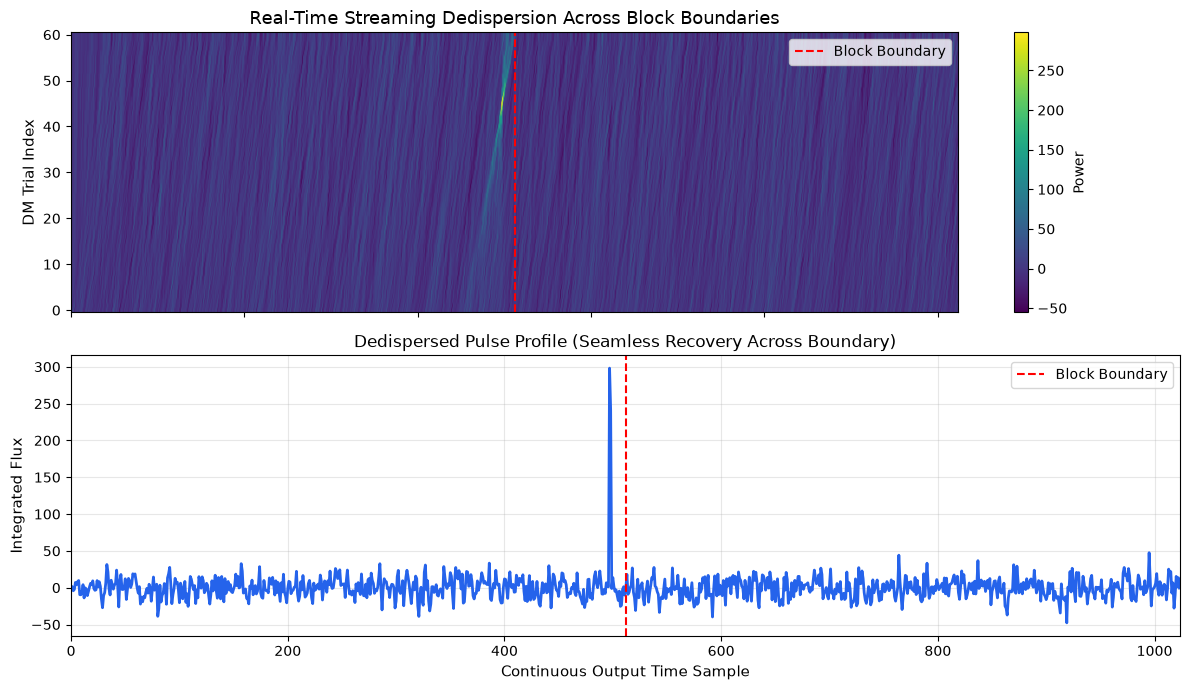

In [3]:
# Visualize the continuous reconstructed DMT stream
peak_dm_idx = np.unravel_index(np.argmax(dmt_stream), dmt_stream.shape)[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# DMT Plane
im = ax1.imshow(dmt_stream, aspect="auto", origin="lower", cmap="viridis")
ax1.axvline(dmt_out0.shape[1], color="red", linestyle="--", lw=1.5, label="Block Boundary")
ax1.set_title("Real-Time Streaming Dedispersion Across Block Boundaries", fontsize=13)
ax1.set_ylabel("DM Trial Index", fontsize=11)
ax1.legend(loc="upper right")
fig.colorbar(im, ax=ax1, label="Power")

# 1D Pulse profile across boundary
ax2.plot(dmt_stream[peak_dm_idx, :], color="#2563eb", lw=2)
ax2.axvline(dmt_out0.shape[1], color="red", linestyle="--", lw=1.5, label="Block Boundary")
ax2.set_title("Dedispersed Pulse Profile (Seamless Recovery Across Boundary)", fontsize=12)
ax2.set_xlabel("Continuous Output Time Sample", fontsize=11)
ax2.set_ylabel("Integrated Flux", fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


## 2. Parking a Stream

`mode="valid"` keeps overlap-save state inside the engine. `save_history()` copies that state out, and `load_history()` puts it back, so one `FDMTCPU` can time-multiplex several beams. `reset_history()` drops the state when the next block is not a continuation.


In [4]:
# Replay block 0, park its history, then restore it before block 1.
fdmt.reset_history()
fdmt.execute(block0)
saved = fdmt.save_history()
print(f"Saved history: {saved.size} floats")

fdmt.reset_history()
fdmt.load_history(saved)
dmt_restored = fdmt.execute(block1)
print(f"Original block-1 peak: {dmt_out1.max():.2f}")
print(f"Restored block-1 peak: {dmt_restored.max():.2f}")


Saved history: 10089 floats
Original block-1 peak: 52.87
Restored block-1 peak: 52.87


## 3. Multi-Beam Batching (`nbeams > 1`)

Modern interferometers form dozens to hundreds of tied-array or synthesized beams simultaneously (e.g. MeerKAT's 1000 tied-array beams).

Instead of instantiating hundreds of independent FDMT objects, pass `nbeams` directly to the constructor:

```python
# Configure FDMT instance for 16 simultaneous beams
nbeams = 16
fdmt_multibeam = FDMTCPU(
    f_min=1200.0,
    f_max=1600.0,
    nchans=256,
    nsamps=1024,
    tsamp=1e-3,
    dt_max=100,
    nbeams=nbeams,
    nthreads=8, # Multi-threaded OpenMP execution
)

# Input waterfall must be a 3D NumPy array of shape (nbeams, nchans, nsamps)
batch_input = np.zeros((nbeams, 256, 1024), dtype=np.float32)

# Output shape will be (nbeams, n_delays, n_times)
batch_output = fdmt_multibeam.execute(batch_input)
print("Batch output shape:", batch_output.shape)
```

Batching amortizes plan lookup overhead, maximizes CPU cache locality, and allows full SIMD vectorization across beams!


In [5]:
nbeams = 4
fdmt_batch = FDMTCPU(
    f_min=f_min,
    f_max=f_max,
    nchans=nchans,
    nsamps=nsamps_block,
    tsamp=tsamp,
    dt_max=dt_max,
    nbeams=nbeams,
    mode="valid",
)
batch = np.zeros((nbeams, nchans, nsamps_block), dtype=np.float32)
batch_out = fdmt_batch.execute(batch)
print(f"Batch input {batch.shape} -> output {batch_out.shape}")


Batch input (4, 128, 512) -> output (4, 61, 512)


## Congratulations!

You have completed the **DMT Tutorial Series**:
For API details, consult the [Python API Reference](../api/python_api.md) and [C++ API Reference](../api/cpp_api.md).
